# Ομαδοποίηση Πυκνότητας Σταθμών Δικτύου με την PROC MODECLUS

## Περίληψη

Μια εταιρεία διανομής ηλεκτρικής ενέργειας χρησιμοποιεί την PROC MODECLUS για να
βρει μη παραμετρικές, βασισμένες σε πυκνότητα συστάδες μεταξύ των σταθμών
παρακολούθησης δικτύου της (υποσταθμοί και αισθητήρες τροφοδοτικών γραμμών)
μόνο από τις χαρτογραφικές τους συντεταγμένες. Η MODECLUS εκτιμά μια επιφάνεια
πυκνότητας πάνω από τους σταθμούς και αντιμετωπίζει τις συστάδες ως περιοχές
υψηλής πυκνότητας που χωρίζονται από κενά χαμηλής πυκνότητας. Εκτελώντας την σε
90 προσομοιωμένους σταθμούς με ακτίνα ομοιόμορφου πυρήνα 3 km ανακτώνται οι τρεις
πυκνές περιοχές εξυπηρέτησης που ενσωματώσαμε στα δεδομένα ως οι τρεις
μεγαλύτερες συστάδες (24, 24 και 21 σταθμοί), ενώ οι διάσπαρτοι αγροτικοί
σταθμοί πέφτουν σε αραιές περιοχές και διαχωρίζονται σε δικές τους μικρο-συστάδες
ενός ή δύο σταθμών. Αυτό το σύνολο απομονωμένων σταθμών είναι το επιχειρησιακό
παραδοτέο: μια λίστα υποψήφιων απομακρυσμένων περιουσιακών στοιχείων για την
ομάδα σχεδιασμού κεφαλαιακών επενδύσεων.

## Πηγές Δεδομένων

| Σύνολο Δεδομένων | Γραμμές | Περιγραφή |
|---------|------|-------------|
| `grid_sites` | 90 | Συνθετικοί σταθμοί παρακολούθησης ηλεκτρικής διανομής, παραγόμενοι εντός του βήματος με `call streaminit(70531)` και `rand()`. Τρεις πυκνές περιοχές εξυπηρέτησης (UrbanCore, Suburban, Industrial) αντλημένες από διμεταβλητές κανονικές κατανομές γύρω από διακριτά κεντροειδή χάρτη, συν 22 διάσπαρτους αγροτικούς (Rural) σταθμούς αντλημένους ομοιόμορφα σε όλη την επικράτεια. |

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `site_id` | Αριθμ. | Μοναδικό αναγνωριστικό σταθμού παρακολούθησης (1-90). |
| `region` | Χαρακτ. | Ετικέτα σχεδιασμού που καταγράφει πώς παρήχθη κάθε σταθμός (Αστικό, Προαστιακό, Βιομηχανικό, Αγροτικό)· κρατείται εκτός της ομαδοποίησης. |
| `x_km`, `y_km` | Αριθμ. | Θέση σταθμού σε χιλιόμετρα στο πλέγμα σχεδιασμού της εταιρείας· οι μεταβλητές ομαδοποίησης. |
| `peak_load_mw` | Αριθμ. | Παρατηρούμενο ετήσιο φορτίο αιχμής (MW) στον σταθμό· μεταφέρεται για ερμηνεία στη συνέχεια. |

# Ομαδοποίηση Πυκνότητας Σταθμών Παρακολούθησης Δικτύου

Μια περιφερειακή εταιρεία διανομής ηλεκτρικής ενέργειας λειτουργεί ένα δίκτυο
**σταθμών παρακολούθησης** - υποσταθμοί και αισθητήρες τροφοδοτικών γραμμών -
διάσπαρτο σε όλη την περιοχή εξυπηρέτησής της. Οι σχεδιαστές θέλουν να
ομαδοποιήσουν αυτούς τους σταθμούς σε φυσικές **περιοχές εξυπηρέτησης** με βάση
αποκλειστικά τη γεωγραφία, χωρίς να προκαθορίζουν πόσες ομάδες υπάρχουν, και να
εντοπίσουν **απομονωμένα αγροτικά περιουσιακά στοιχεία** που δεν ανήκουν σε
καμία πυκνή περιοχή.

Η `PROC MODECLUS` είναι κατάλληλη για αυτό: εκτελεί *μη παραμετρική, βασισμένη
σε πυκνότητα* ομαδοποίηση. Εκτιμά μια συνάρτηση πυκνότητας πάνω από τους
σταθμούς, και στη συνέχεια αντιμετωπίζει τις συστάδες ως περιοχές υψηλής
πυκνότητας σταθμών που χωρίζονται από κενά χαμηλής πυκνότητας. Οι αραιές
ακραίες τιμές καταλήγουν στις δικές τους μικροσκοπικές συστάδες αντί να
απορροφηθούν σε μια περιοχή - ακριβώς η συμπεριφορά που θέλουμε για την
επισήμανση απομακρυσμένων σταθμών.

Αυτό το σημειωματάριο:
1. Δημιουργεί ένα ρεαλιστικό συνθετικό δίκτυο 90 σταθμών.
2. Εκτιμά την πυκνότητα σταθμών με **ομοιόμορφο πυρήνα** και σαρώνει την ακτίνα
   εξομάλυνσης `R=` για να επιβεβαιώσει ότι οι ανακτημένες περιοχές είναι
   σταθερές.
3. Καθορίζει μια ακτίνα εργασίας, γράφει ένα σύνολο δεδομένων `OUT=` με την
   πυκνότητα και την ετικέτα συστάδας κάθε σταθμού, και χαρτογραφεί το
   αποτέλεσμα.

## Βήμα 1 -- Δημιουργία ενός συνθετικού δικτύου σταθμών παρακολούθησης

Προσομοιώνουμε 90 σταθμούς. Τρεις πυκνές **περιοχές εξυπηρέτησης** αντλούνται
από διμεταβλητές κανονικές κατανομές γύρω από διακριτά κεντροειδή χάρτη (Αστικό
κοντά στο (12, 30), Προαστιακό κοντά στο (30, 15), Βιομηχανικό κοντά στο (20,
42)), δίνοντας συμπαγή, υψηλής πυκνότητας σύνολα των 24, 24 και 20 σταθμών.
Ένα τέταρτο σύνολο 22 **Αγροτικών** σταθμών αντλείται ομοιόμορφα σε όλη την
επικράτεια, παράγοντας τους αραιούς, διάσπαρτους σταθμούς που μια εταιρεία θα
αντιμετώπιζε ως απομονωμένους.

Η ετικέτα `region` καταγράφει πώς παρήχθη κάθε σταθμός· την κρατάμε σκόπιμα
**εκτός** της ομαδοποίησης ώστε η MODECLUS να ανακαλύψει εκ νέου τη δομή μόνο
από τις συντεταγμένες. Το `peak_load_mw` μεταφέρεται για ερμηνεία στη
συνέχεια.

In [1]:
ΔΕΔΟΜΕΝΑ grid_sites;
   CALL streaminit(70531);
   LENGTH region $ 40;

   /* Πυκνή αστική περιοχή εξυπηρέτησης */
   ΕΠΑΝΑΛΗΨΗ site_id = 1 ΕΩΣ 24;
      region = 'Αστικό';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;

   /* Προαστιακή περιοχή */
   ΕΠΑΝΑΛΗΨΗ site_id = 25 ΕΩΣ 48;
      region = 'Προαστιακό';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;

   /* Βιομηχανική περιοχή (υψηλότερο φορτίο αιχμής) */
   ΕΠΑΝΑΛΗΨΗ site_id = 49 ΕΩΣ 68;
      region = 'Βιομηχανικό';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;

   /* Διάσπαρτοι αγροτικοί σταθμοί (αραιοί, χαμηλό φορτίο) */
   ΕΠΑΝΑΛΗΨΗ site_id = 69 ΕΩΣ 90;
      region = 'Αγροτικό';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

TITLE 'Συνθετικοί Σταθμοί Παρακολούθησης Δικτύου';
ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=grid_sites n mean std MIN MAX maxdec=2;
   ΚΛΑΣΗ region;
   ΜΕΤΑΒΛΗΤΗ x_km y_km peak_load_mw;
   ΕΤΙΚΕΤΑ region='Περιοχή' x_km='Ανατολικά (km)' y_km='Βόρεια (km)' peak_load_mw='Μέγιστο Φορτίο (MW)';
ΕΚΤΕΛΕΣΗ;


                                       Συνθετικοί Σταθμοί Παρακολούθησης Δικτύου                                        

                                                  The MEANS Procedure

                                    Analysis Variable : x_km Ανατολικά (km)

        Περιοχή                         N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------------------
        Αγροτικό                           22          29.79          10.62          11.06          47.45
        Αστικό                             24          12.07           1.34           8.65          14.42
        Βιομηχανικό                        20          20.36           0.96          18.52          21.53
        Προαστιακό                         24          29.96           1.73          26.51          33.60
        --------------------------------------------------------------------------------------


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Συνθετικοί Σταθμοί Παρακολούθησης Δικτύου.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Οι μέσοι όροι επιβεβαιώνουν τρεις σφιχτές περιοχές και μία διάχυτη ομάδα. Οι
τρεις πυκνές περιοχές έχουν μικρές τυπικές αποκλίσεις συντεταγμένων (περίπου
1-1.7 km σε κάθε άξονα) γύρω από καλά διαχωρισμένα κεντροειδή, ενώ η αγροτική
ομάδα εξαπλώνεται σε όλο το πλέγμα (τυπικές αποκλίσεις πάνω από 10 km και στους
δύο άξονες). Το φορτίο αιχμής επίσης διαχωρίζει τις περιοχές -- η Βιομηχανική
έχει κατά μέσο όρο περίπου 6 MW, η Αστική περίπου 4.6 MW, η Προαστιακή περίπου
2.7 MW, και η Αγροτική περίπου 1.5 MW -- κάτι που είναι χρήσιμο πλαίσιο μόλις
βρεθούν οι γεωγραφικές συστάδες.

## Βήμα 2 -- Ομαδοποίηση πυκνότητας ομοιόμορφου πυρήνα και σάρωση ακτίνας

Η εκτίμηση πυκνότητας ομοιόμορφου πυρήνα χρησιμοποιεί μια **ακτίνα `R=`**: κάθε
σταθμός εντός `R` χιλιομέτρων συνεισφέρει στην τοπική πυκνότητα ενός σταθμού.
Μικρό `R` δίνει μια ασταθή πυκνότητα που κατακερματίζει την επικράτεια· μεγάλο
`R` υπερεξομαλύνει και συγχωνεύει τις περιοχές. Ένας ειδικός SAS ποτέ δεν
εμπιστεύεται μία μόνο τιμή -- σαρώνει ένα εύρος ακτίνων και ψάχνει για έναν
αριθμό συστάδων που είναι **σταθερός**, όπου οι πυκνές περιοχές επιμένουν ενώ
μόνο ο αριθμός των διάσπαρτων μεμονωμένων σταθμών μεταβάλλεται.

Εδώ το `M=1` επιλέγει τη μέθοδο ομαδοποίησης 1 (η τυπική μη παραμετρική
μέθοδος), και ζητάμε ακτίνες `R=2.5 έως 4 κατά 0.5` σε μία κλήση. Η MODECLUS
εκτελεί την ανάλυση μία φορά ανά ακτίνα και αναφέρει τον αριθμό συστάδων για
κάθε μία. Το `SHORT` καταστέλλει τα λεπτομερή στατιστικά ανά συστάδα.

In [2]:
TITLE 'Ομαδοποίηση Πυκνότητας Ομοιόμορφου Πυρήνα των Σταθμών Δικτύου';
title2 'Σάρωση Ακτίνας R = 2.5 έως 4.0 km';

ΔΙΑΔΙΚΑΣΙΑ modeclus ΔΕΔΟΜΕΝΑ=grid_sites m=1 r=2.5 ΕΩΣ 4 ΚΑΤΑ 0.5 short;
   ΜΕΤΑΒΛΗΤΗ x_km y_km;
   id site_id;
ΕΚΤΕΛΕΣΗ;


                             Ομαδοποίηση Πυκνότητας Ομοιόμορφου Πυρήνα των Σταθμών Δικτύου                              
                                           Σάρωση Ακτίνας R = 2.5 έως 4.0 km                                            


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Ομαδοποίηση Πυκνότητας Ομοιόμορφου Πυρήνα των Σταθμών Δικτύου.
NOTE: Option TITLE2 changed to Σάρωση Ακτίνας R = 2.5 έως 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Ο αριθμός συστάδων μετακινείται μόνο ήπια στη σάρωση -- 23 συστάδες στο
`R=2.5`, 22 στο `R=3.0`, 19 στο `R=3.5`, και 18 στο `R=4.0`. Οι υψηλοί ακατέργαστοι
αριθμοί προέρχονται από τους διάσπαρτους αγροτικούς σταθμούς: κάθε
απομονωμένος σταθμός βρίσκεται στη δική του αραιή γειτονιά και σχηματίζει μια
συστάδα ενός σταθμού, οπότε οι περισσότερες από τις 18-23 "συστάδες" είναι
μεμονωμένες. Αυτό που παραμένει σταθερό από κάτω είναι η δομή που έχει σημασία
-- οι τρεις πυκνές περιοχές παραμένουν τρεις μεγάλες, καλά διαχωρισμένες
συστάδες σε κάθε ακτίνα. Καθώς το `R` διευρύνεται, μερικοί από τους διάσπαρτους
μεμονωμένους σταθμούς συγχωνεύονται με έναν γείτονα ή μια κοντινή περιοχή, γι'
αυτό ο συνολικός αριθμός μειώνεται αργά αντί να ταλαντεύεται άγρια. Αυτή η
σταθερότητα είναι το σήμα ότι η λύση των τριών περιοχών είναι πραγματική και
όχι ένα τεχνούργημα ενός εύρους ζώνης.

## Βήμα 3 -- Τελική λύση συστάδων για χαρτογράφηση

Αφού είδαμε ότι οι τρεις περιοχές είναι σταθερές σε όλη τη σάρωση, καθορίζουμε
μία ενιαία ακτίνα εργασίας (`R=3` km) και ζητάμε την επιλογή **ALL** για την
πλήρη εμφάνιση ανά συστάδα, συν το **OUT=** για να γράψουμε τις αρχικές
συντεταγμένες μαζί με την εκτίμηση `DENSITY` και την ανάθεση `CLUSTER` ώστε να
μπορούμε να χαρτογραφήσουμε το αποτέλεσμα. Οι συστάδες αριθμούνται κατά
φθίνουσα πυκνότητα κορυφής, οπότε οι πυκνότερες περιοχές είναι οι συστάδες 1,
2 και 3 και οι αραιοί σταθμοί παίρνουν τους υψηλότερους αριθμούς.

In [3]:
TITLE 'Τελική Λύση Συστάδων Βασισμένη σε Πυκνότητα';
title2 'Ομοιόμορφος πυρήνας, R = 3 km';

ΔΙΑΔΙΚΑΣΙΑ modeclus ΔΕΔΟΜΕΝΑ=grid_sites m=1 r=3 out=join_out ALL;
   ΜΕΤΑΒΛΗΤΗ x_km y_km;
   id site_id;
ΕΚΤΕΛΕΣΗ;


                                      Τελική Λύση Συστάδων Βασισμένη σε Πυκνότητα                                       
                                             Ομοιόμορφος πυρήνας, R = 3 km                                              


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
      


NOTE: Option TITLE changed to Τελική Λύση Συστάδων Βασισμένη σε Πυκνότητα.
NOTE: Option TITLE2 changed to Ομοιόμορφος πυρήνας, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Η Σύνοψη Συστάδων καθιστά τη δομή σαφή. Η λύση `R=3` επιστρέφει **22
συστάδες**, αλλά είναι έντονα διαβαθμισμένες κατά πυκνότητα:

- **Συστάδα 1** -- 24 σταθμοί, πυκνότητα κορυφής περίπου 0.0090 (η Αστική
  περιοχή).
- **Συστάδα 2** -- 24 σταθμοί, πυκνότητα κορυφής περίπου 0.0079 (η Προαστιακή
  περιοχή).
- **Συστάδα 3** -- 21 σταθμοί, πυκνότητα κορυφής περίπου 0.0079 (η Βιομηχανική
  περιοχή· παίρνει έναν αγροτικό σταθμό που έτυχε να πέσει στο άκρο της).
- **Συστάδες 4-22** -- μια τριμελής ομάδα και δεκαοκτώ μονομελείς συστάδες,
  όλες σε πυκνότητα κορυφής περίπου 0.0004, περίπου είκοσι φορές πιο αραιές
  από τις περιοχές.

Οι τρεις πυκνές περιοχές αντιπροσωπεύουν 69 από τους 90 σταθμούς· οι υπόλοιποι
21 σταθμοί είναι τα διάσπαρτα αγροτικά περιουσιακά στοιχεία, ο καθένας
μόνος του ή σχεδόν μόνος του σε μια γειτονιά χαμηλής πυκνότητας. Η
πυκνότητα, όχι ένας προκαθορισμένος αριθμός συστάδων, χαράσσει τη γραμμή
μεταξύ μιας περιοχής εξυπηρέτησης και ενός απομονωμένου σταθμού.

## Βήμα 4 -- Χαρτογράφηση των συστάδων

Επισημαίνουμε κάθε σταθμό ανάλογα με το αν βρέθηκε σε μία από τις τρεις πυκνές
περιοχές (`cluster <= 3`) ή σε μια αραιή μικρο-συστάδα, και στη συνέχεια
σχεδιάζουμε κάθε σταθμό στις χαρτογραφικές του συντεταγμένες χρωματισμένο
ανάλογα με αυτή την κατάσταση. Αυτή είναι η οπτική του σχεδιαστή: πυκνές
περιοχές προς διαχείριση ως περιοχές εξυπηρέτησης, και απομονωμένοι σταθμοί
προς επισήμανση για ξεχωριστή αντιμετώπιση.

                               Ανακτημένες Περιοχές Εξυπηρέτησης και Απομονωμένοι Σταθμοί                               
                                  Ομαδοποίηση πυκνότητας ομοιόμορφου πυρήνα, R = 3 km                                   




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Ανακτημένες Περιοχές Εξυπηρέτησης και Απομονωμένοι Σταθμοί.
NOTE: Option TITLE2 changed to Ομαδοποίηση πυκνότητας ομοιόμορφου πυρήνα, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


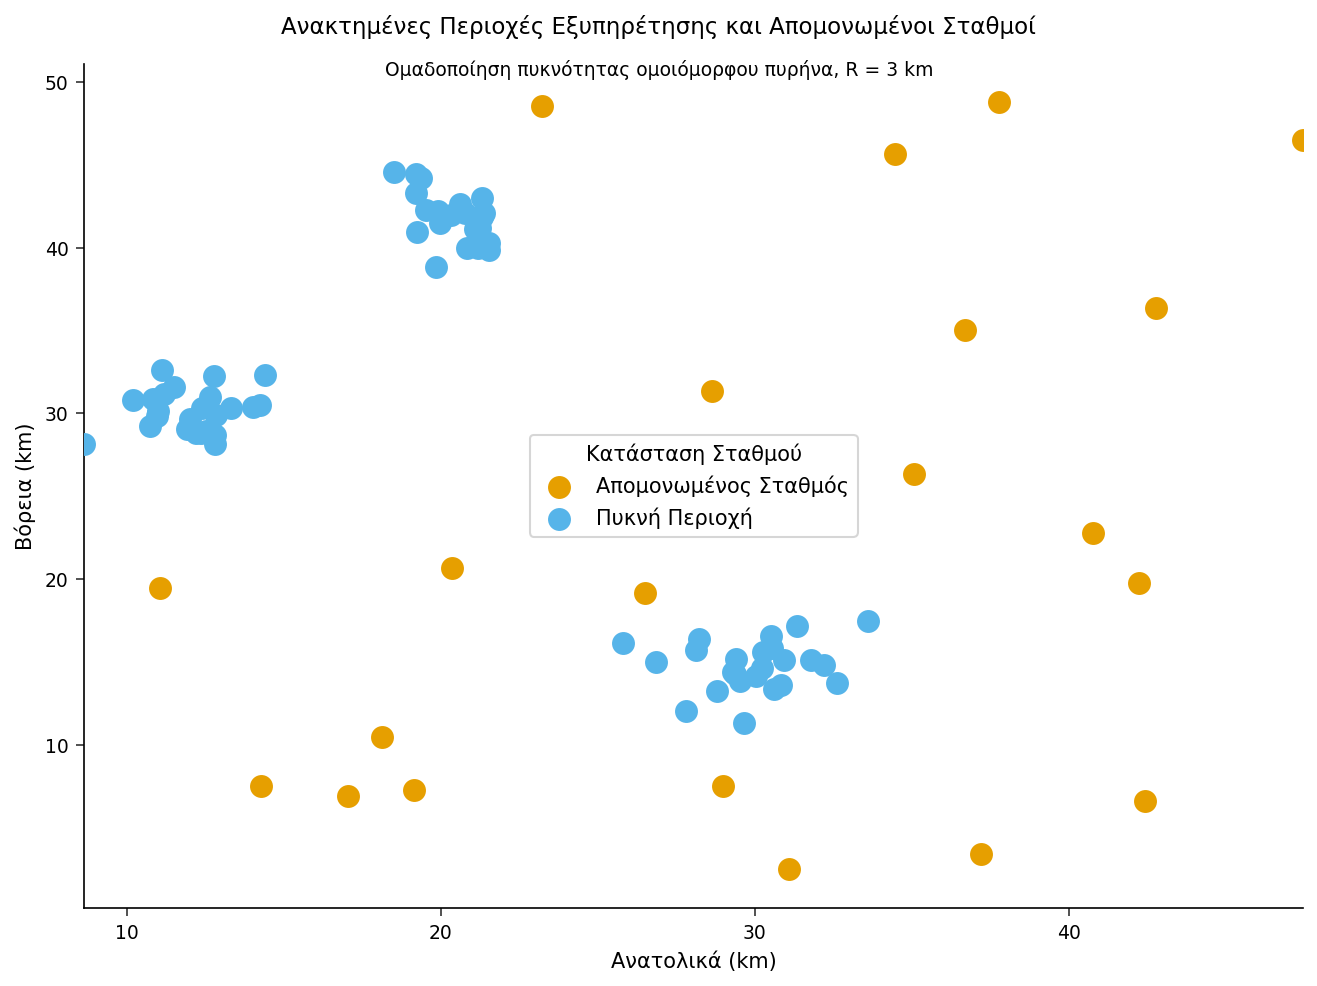

In [4]:
ΔΕΔΟΜΕΝΑ mapped;
   ΟΡΙΣΜΟΣ join_out;
   LENGTH status $ 40;
   ΕΑΝ CLUSTER <= 3 ΤΟΤΕ status = 'Πυκνή Περιοχή';
   ΑΛΛΙΩΣ status = 'Απομονωμένος Σταθμός';
ΕΚΤΕΛΕΣΗ;

TITLE 'Ανακτημένες Περιοχές Εξυπηρέτησης και Απομονωμένοι Σταθμοί';
title2 'Ομαδοποίηση πυκνότητας ομοιόμορφου πυρήνα, R = 3 km';
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS ΕΤΙΚΕΤΑ='Ανατολικά (km)';
   YAXIS ΕΤΙΚΕΤΑ='Βόρεια (km)';
   keylegend / TITLE='Κατάσταση Σταθμού';
ΕΚΤΕΛΕΣΗ;

TITLE;


## Ερμηνεία των αποτελεσμάτων

**Τι βρήκε η MODECLUS.** Καθοδηγούμενη μόνο από το `(x_km, y_km)`, η διαδικασία
ανακτά τις τρεις πυκνές περιοχές εξυπηρέτησης που ενσωματώσαμε στα δεδομένα --
τις περιοχές Αστικό, Προαστιακό και Βιομηχανικό -- ως τις τρεις μεγαλύτερες,
πυκνότερες συστάδες (24, 24 και 21 σταθμοί). Οι διάσπαρτοι αγροτικοί σταθμοί,
αντλημένοι ομοιόμορφα σε όλη την επικράτεια, πέφτουν σε αραιές περιοχές και
διαχωρίζονται στις δικές τους συστάδες ενός ή δύο σταθμών αντί να απορροφηθούν
σε μια περιοχή. Στον χάρτη είναι τα σημεία που διαχωρίζονται από τις τρεις
σφιχτές ομάδες. Αυτό το απομονωμένο σύνολο είναι το επιχειρησιακό παραδοτέο:
μια λίστα υποψήφιων απομακρυσμένων περιουσιακών στοιχείων για την ομάδα
σχεδιασμού κεφαλαιακών επενδύσεων.

**Γιατί έχει σημασία η σάρωση εξομάλυνσης.** Καμία μεμονωμένη τιμή `R` δεν
είναι αυθεντική για μη παραμετρική ομαδοποίηση πυκνότητας. Η σάρωση `R=2.5 έως
4 κατά 0.5` μας επιτρέπει να επιβεβαιώσουμε ότι οι περιοχές είναι *σταθερές*
σε διαφορετικά επίπεδα εξομάλυνσης αντί να είναι τεχνούργημα ενός εύρους
ζώνης. Στη σάρωση ο αριθμός συστάδων μετακινείται μόνο από 23 σε 18, και η
αλλαγή είναι εξ ολοκλήρου στον αριθμό των διάσπαρτων μεμονωμένων σταθμών -- οι
τρεις πυκνές περιοχές επιμένουν καθ' όλη τη διάρκεια. Όπου η δομή παρέμεινε
σταθερή έτσι, έχουμε μια υπερασπίσιμη λύση· αν ο αριθμός είχε ταλαντευτεί
άγρια, η δομή θα ήταν εύθραυστη και δεν θα έπρεπε να καθοδηγεί επενδυτικές
αποφάσεις.

**Η πυκνότητα διαβαθμίζει το αποτέλεσμα.** Επειδή οι συστάδες αριθμούνται κατά
φθίνουσα πυκνότητα κορυφής, ο διαχωρισμός μεταξύ περιοχών και απομονωμένων
σταθμών είναι ποσοτικός, όχι αυθαίρετος: οι τρεις περιοχές βρίσκονται κοντά
στην πυκνότητα κορυφής 0.008-0.009 ενώ κάθε απομονωμένος σταθμός βρίσκεται
κοντά στο 0.0004, περίπου είκοσι φορές πιο αραιά. Ένας σχεδιαστής μπορεί να
ορίσει ένα κατώφλι πυκνότητας και να διαβάσει τα απομονωμένα περιουσιακά
στοιχεία απευθείας από τις στήλες `CLUSTER` και `DENSITY` του `join_out`.

**Πρακτική χρήση.** Το σύνολο δεδομένων `join_out` δίνει σε κάθε σταθμό μια
πυκνότητα και μια ετικέτα συστάδας που μπορεί να τροφοδοτήσει επόμενες
εργασίες -- προσαρμογή μεγέθους συνεργείων και ανταλλακτικών ανά περιοχή
εξυπηρέτησης, δρομολόγηση κυκλωμάτων επιθεώρησης, ή ιεράρχηση ενίσχυσης
δικτύου στη πυκνή βιομηχανική συστάδα (υψηλότερο `peak_load_mw`, περίπου 6 MW)
ενώ προγραμματίζονται οι απομονωμένοι αγροτικοί σταθμοί για ξεχωριστή,
χαμηλότερης συχνότητας συντήρηση.

*Σημείωση για τα συνθετικά δεδομένα:* οι συντεταγμένες και τα φορτία
προσομοιώνονται με σταθερό σπόρο (`call streaminit(70531)`) ώστε το
σημειωματάριο να είναι πλήρως αναπαραγώγιμο εκτός σύνδεσης· σε πραγματικά
δεδομένα εταιρείας θα αντικαθιστούσατε τις μετρημένες συντεταγμένες σταθμών
και τα μετρημένα φορτία αιχμής. Ο ακριβής αριθμός συστάδων εξαρτάται από την
τυχαία κλήρωση και την επιλεγμένη ακτίνα.